Cancer prediction: survival x treatment

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("oral_cancer_prediction_dataset.csv")

In [2]:
df

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84917,84918,USA,46,Male,Yes,No,No,No,No,Yes,...,No,Yes,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
84918,84919,USA,41,Male,Yes,Yes,No,No,No,No,...,Yes,Yes,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
84919,84920,Taiwan,72,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,4.777394,1,Surgery,85.633426,81352.50,90,No,Yes
84920,84921,Japan,67,Male,Yes,No,No,No,No,No,...,Yes,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No


In [3]:
#check for null values: no nulls!

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [4]:
#value counts for treatment type

df["Treatment Type"].value_counts()

Treatment Type
No Treatment        51016
Chemotherapy         8529
Surgery              8500
Targeted Therapy     8465
Radiation            8412
Name: count, dtype: int64

In [5]:
#uniques in each columns

df.nunique(dropna=False)

ID                                          84922
Country                                        17
Age                                            83
Gender                                          2
Tobacco Use                                     2
Alcohol Consumption                             2
HPV Infection                                   2
Betel Quid Use                                  2
Chronic Sun Exposure                            2
Poor Oral Hygiene                               2
Diet (Fruits & Vegetables Intake)               3
Family History of Cancer                        2
Compromised Immune System                       2
Oral Lesions                                    2
Unexplained Bleeding                            2
Difficulty Swallowing                           2
White or Red Patches in Mouth                   2
Tumor Size (cm)                             42350
Cancer Stage                                    5
Treatment Type                                  5


In [6]:
#check for duplicates

df.duplicated().sum()

np.int64(0)

In [7]:
#describe to see the dataset

df.describe(include="all")

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
count,84922.000000,84922,84922.000000,84922,84922,84922,84922,84922,84922,84922,...,84922,84922,84922.000000,84922.000000,84922,84922.000000,84922.000000,84922.000000,84922,84922
unique,NaN,17,NaN,2,2,2,2,2,2,2,...,2,2,NaN,NaN,5,NaN,NaN,NaN,2,2
top,NaN,India,NaN,Male,Yes,Yes,No,No,No,No,...,No,No,NaN,NaN,No Treatment,NaN,NaN,NaN,Yes,No
freq,NaN,8079,NaN,60351,67989,50939,59525,60299,68057,42627,...,63709,55103,NaN,NaN,51016,NaN,NaN,NaN,46508,42573
mean,42461.500000,NaN,54.509444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.747294,1.118756,NaN,79.503364,39109.881244,52.028391,NaN,NaN
std,24515.014117,NaN,10.014839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.028199,1.340418,NaN,26.483746,44710.687054,60.389796,NaN,NaN
min,1.000000,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,NaN,10.000750,0.000000,0.000000,NaN,NaN
25%,21231.250000,NaN,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,NaN,65.233425,0.000000,0.000000,NaN,NaN
50%,42461.500000,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,0.000000,NaN,100.000000,0.000000,0.000000,NaN,NaN
75%,63691.750000,NaN,61.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.480075,2.000000,NaN,100.000000,76468.437500,104.000000,NaN,NaN


In [8]:
# strip + lowercase
df['treatment'] = df['Treatment Type'].str.strip().str.lower()
df['early_dx'] = df['Early Diagnosis'].str.strip().str.lower()
df['tobacco'] = df['Tobacco Use'].str.strip().str.lower()

# stage as int
df['stage'] = pd.to_numeric(df['Cancer Stage'], errors='coerce').astype('Int64')

# sanity checks
assert df['treatment'].isna().sum() == 0
assert df['early_dx'].isna().sum() == 0
assert df['tobacco'].isna().sum() == 0


In [9]:
df['age_group'] = pd.cut(df['Age'], bins=[0, 34, 44, 54, 64, 120],
                         labels=['<35','35-44','45-54','55-64','65+'])

df['tumor_bin'] = pd.cut(df['Tumor Size (cm)'],
                         bins=[0, 1, 2, 4, 8, 100],
                         labels=['<=1','1-2','2-4','4-8','8+'])


In [10]:
overall = df.groupby('treatment')['Survival Rate (5-Year, %)'].agg(['count','mean','median'])
overall.sort_values('median', ascending=False)


,count,mean,median
treatment,,,
no treatment,51016,93.216543,100.000000
targeted therapy,8465,59.066850,65.311229
radiation,8412,58.984642,65.282473
surgery,8500,58.754779,65.185763
chemotherapy,8529,58.676772,64.728185


In [11]:
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,0.00,0,No,No,no treatment,no,yes,0,35-44,NaN
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,77772.50,177,No,Yes,no treatment,no,yes,1,55-64,1-2
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,101164.50,130,Yes,Yes,surgery,yes,no,2,35-44,2-4
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,0.00,0,Yes,No,no treatment,yes,yes,0,55-64,NaN
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,45354.75,52,No,Yes,no treatment,no,no,3,65+,2-4


In [12]:
by_stage = (df.groupby(['stage','treatment'])['Survival Rate (5-Year, %)']
              .agg(['count','mean','median'])
              .reset_index())

by_stage

,stage,treatment,count,mean,median
0,0,no treatment,42573,100.000000,100.000000
1,1,chemotherapy,2548,85.007953,84.978965
2,1,no treatment,2564,84.958118,84.968222
3,1,radiation,2524,85.061496,85.095917
4,1,surgery,2556,84.905082,84.927428
5,1,targeted therapy,2521,84.990971,84.975730
6,2,chemotherapy,2564,67.376059,67.289390
7,2,no treatment,2528,67.497024,67.497096
8,2,radiation,2582,67.486782,67.473079
9,2,surgery,2546,67.571468,67.531203


In [13]:
by_stage_early = (df.groupby(['stage','early_dx','treatment'])['Survival Rate (5-Year, %)']
                    .median()
                    .reset_index(name='median_survival'))

by_stage_early

,stage,early_dx,treatment,median_survival
0,0,no,no treatment,100.000000
1,0,yes,no treatment,100.000000
2,1,no,chemotherapy,85.110924
3,1,no,no treatment,84.986496
4,1,no,radiation,85.102749
5,1,no,surgery,84.867379
6,1,no,targeted therapy,85.004623
7,1,yes,chemotherapy,84.860900
8,1,yes,no treatment,84.929176
9,1,yes,radiation,85.059983


<Axes: xlabel='treatment', ylabel='Survival Rate (5-Year, %)'>

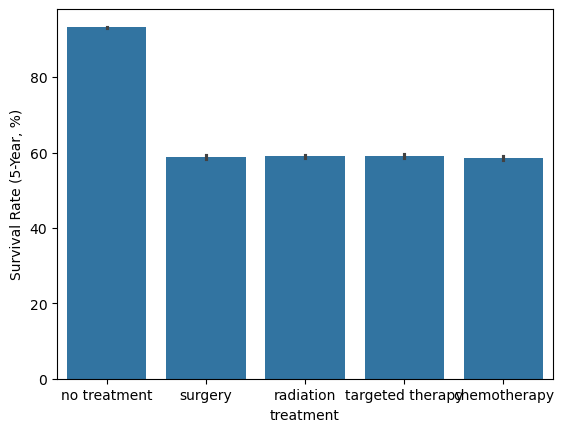

In [14]:
sns.barplot(data=df, x="treatment", y="Survival Rate (5-Year, %)")

In [15]:
df_diagn=df[df["Oral Cancer (Diagnosis)"] == "Yes"]
df_diagn

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,77772.50,177,No,Yes,no treatment,no,yes,1,55-64,1-2
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,101164.50,130,Yes,Yes,surgery,yes,no,2,35-44,2-4
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,45354.75,52,No,Yes,no treatment,no,no,3,65+,2-4
5,6,Taiwan,70,Male,Yes,No,Yes,Yes,No,Yes,...,96504.00,91,Yes,Yes,surgery,yes,yes,2,65+,1-2
6,7,USA,41,Female,Yes,Yes,No,No,No,No,...,86131.25,105,Yes,Yes,no treatment,yes,yes,1,35-44,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84907,84908,Pakistan,59,Male,Yes,No,Yes,Yes,No,No,...,77262.00,142,No,Yes,surgery,no,yes,2,55-64,2-4
84909,84910,Brazil,59,Male,Yes,Yes,Yes,No,Yes,Yes,...,91005.00,162,Yes,Yes,radiation,yes,yes,1,55-64,2-4
84912,84913,India,42,Male,Yes,Yes,No,No,No,No,...,54436.00,163,No,Yes,chemotherapy,no,yes,4,35-44,2-4
84914,84915,France,66,Male,Yes,Yes,Yes,No,No,No,...,39346.25,167,No,Yes,radiation,no,yes,1,65+,4-8


<Axes: xlabel='treatment', ylabel='Survival Rate (5-Year, %)'>

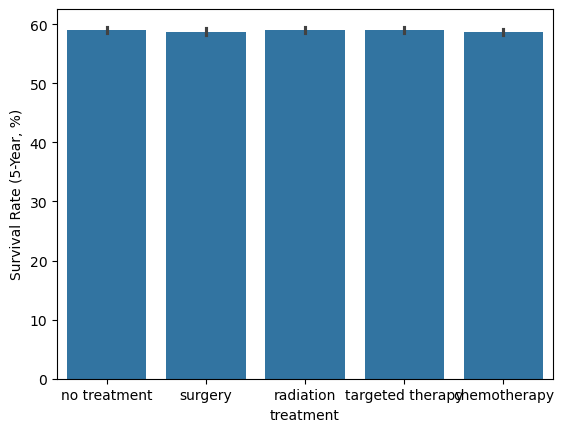

In [16]:
sns.barplot(data=df_diagn, x="treatment", y="Survival Rate (5-Year, %)")

In [17]:
df['ID'] = df['ID'].astype(str)

In [18]:
#df.to_csv("cancer_survival1.csv", index=False)

Statistical analysis

In [19]:
df_surg = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["age_group"] == "65+") &
    (df["stage"] == 1) &
    (df["treatment"] == "surgery")
]

df_surg

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
1163,1164,India,67,Female,Yes,No,No,Yes,Yes,Yes,...,30990.00,121,Yes,Yes,surgery,yes,yes,1,65+,4-8
1266,1267,Egypt,69,Male,Yes,Yes,No,No,No,No,...,49263.75,80,Yes,Yes,surgery,yes,yes,1,65+,4-8
1340,1341,Italy,65,Male,Yes,No,No,No,No,No,...,44263.75,31,Yes,Yes,surgery,yes,yes,1,65+,1-2
2362,2363,India,74,Male,Yes,Yes,No,No,No,No,...,45483.75,152,Yes,Yes,surgery,yes,yes,1,65+,2-4
2887,2888,Italy,66,Female,Yes,No,No,No,Yes,No,...,47293.75,124,Yes,Yes,surgery,yes,yes,1,65+,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82690,82691,Taiwan,67,Male,Yes,Yes,No,No,No,Yes,...,55925.00,116,Yes,Yes,surgery,yes,yes,1,65+,2-4
83160,83161,USA,65,Male,Yes,No,No,No,No,No,...,81626.25,75,Yes,Yes,surgery,yes,yes,1,65+,2-4
83607,83608,Germany,69,Female,No,Yes,Yes,Yes,Yes,Yes,...,26156.25,76,Yes,Yes,surgery,yes,no,1,65+,2-4
83713,83714,USA,65,Male,Yes,Yes,No,No,No,No,...,91672.50,81,Yes,Yes,surgery,yes,yes,1,65+,2-4


In [20]:
df_rad = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["age_group"] == "65+") &
    (df["stage"] == 1) &
    (df["treatment"] == "radiation")
]

df_rad

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
87,88,Taiwan,69,Male,Yes,Yes,No,Yes,No,No,...,55086.25,63,Yes,Yes,radiation,yes,yes,1,65+,2-4
229,230,Germany,69,Male,Yes,Yes,No,No,Yes,Yes,...,72401.25,46,Yes,Yes,radiation,yes,yes,1,65+,2-4
1079,1080,France,70,Male,No,No,No,No,No,No,...,60500.00,165,Yes,Yes,radiation,yes,no,1,65+,4-8
1609,1610,Brazil,69,Male,Yes,Yes,No,No,No,No,...,91852.50,124,Yes,Yes,radiation,yes,yes,1,65+,4-8
2739,2740,Taiwan,66,Female,Yes,Yes,No,Yes,No,No,...,93006.25,48,Yes,Yes,radiation,yes,yes,1,65+,1-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83118,83119,Taiwan,66,Male,No,Yes,No,Yes,Yes,Yes,...,78711.25,113,Yes,Yes,radiation,yes,no,1,65+,1-2
84059,84060,Kenya,68,Male,Yes,No,No,No,No,No,...,60261.25,53,Yes,Yes,radiation,yes,yes,1,65+,2-4
84211,84212,Pakistan,70,Male,No,Yes,No,No,No,Yes,...,39055.00,134,Yes,Yes,radiation,yes,no,1,65+,2-4
84710,84711,France,66,Male,Yes,No,No,No,Yes,Yes,...,54923.75,125,Yes,Yes,radiation,yes,yes,1,65+,1-2


In [21]:
df_chem = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["age_group"] == "65+") &
    (df["stage"] == 1) &
    (df["treatment"] == "chemotherapy")
]

df_chem

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
187,188,USA,68,Male,Yes,Yes,No,No,No,No,...,33958.75,67,Yes,Yes,chemotherapy,yes,yes,1,65+,4-8
231,232,India,65,Male,No,No,No,Yes,No,Yes,...,78720.00,130,Yes,Yes,chemotherapy,yes,no,1,65+,1-2
444,445,Taiwan,70,Male,Yes,No,Yes,No,No,Yes,...,28178.75,90,Yes,Yes,chemotherapy,yes,yes,1,65+,1-2
1698,1699,Germany,68,Male,Yes,Yes,No,No,No,No,...,78391.25,36,Yes,Yes,chemotherapy,yes,yes,1,65+,1-2
2840,2841,Germany,72,Male,No,Yes,Yes,No,No,No,...,97482.50,94,Yes,Yes,chemotherapy,yes,no,1,65+,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81021,81022,Nigeria,66,Female,Yes,No,No,No,No,No,...,53923.75,48,Yes,Yes,chemotherapy,yes,yes,1,65+,4-8
82453,82454,USA,66,Male,No,Yes,No,No,No,No,...,77602.50,101,Yes,Yes,chemotherapy,yes,no,1,65+,2-4
83185,83186,Nigeria,67,Male,Yes,No,Yes,No,No,Yes,...,82488.75,76,Yes,Yes,chemotherapy,yes,yes,1,65+,4-8
83986,83987,Germany,65,Male,Yes,Yes,No,No,Yes,Yes,...,86896.25,75,Yes,Yes,chemotherapy,yes,yes,1,65+,2-4


In [22]:
df_targ = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["age_group"] == "65+") &
    (df["stage"] == 1) &
    (df["treatment"] == "targeted therapy")
]

df_targ

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
106,107,Italy,65,Male,Yes,No,No,No,No,No,...,63181.25,174,Yes,Yes,targeted therapy,yes,yes,1,65+,2-4
1245,1246,France,78,Female,Yes,Yes,No,No,No,Yes,...,93223.75,136,Yes,Yes,targeted therapy,yes,yes,1,65+,1-2
1335,1336,Australia,66,Male,Yes,Yes,No,No,No,Yes,...,44960.00,130,Yes,Yes,targeted therapy,yes,yes,1,65+,1-2
2252,2253,Australia,75,Male,Yes,No,No,No,Yes,No,...,42213.75,78,Yes,Yes,targeted therapy,yes,yes,1,65+,2-4
2382,2383,Taiwan,68,Male,Yes,Yes,No,Yes,Yes,No,...,40158.75,131,Yes,Yes,targeted therapy,yes,yes,1,65+,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82111,82112,India,65,Female,Yes,Yes,No,No,No,Yes,...,57746.25,50,Yes,Yes,targeted therapy,yes,yes,1,65+,4-8
82183,82184,Italy,66,Male,No,Yes,Yes,No,No,Yes,...,27800.00,154,Yes,Yes,targeted therapy,yes,no,1,65+,1-2
82381,82382,Brazil,65,Male,Yes,No,No,No,No,Yes,...,54230.00,171,Yes,Yes,targeted therapy,yes,yes,1,65+,4-8
83332,83333,Japan,66,Male,Yes,No,No,No,Yes,Yes,...,72195.00,91,Yes,Yes,targeted therapy,yes,yes,1,65+,4-8


In [23]:
df_notreat = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["age_group"] == "65+") &
    (df["stage"] == 1) &
    (df["treatment"] == "no treatment")
]

df_notreat

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
228,229,South Africa,69,Female,Yes,Yes,No,No,No,No,...,96786.25,174,Yes,Yes,no treatment,yes,yes,1,65+,4-8
302,303,Nigeria,76,Male,Yes,Yes,No,No,Yes,No,...,60995.00,58,Yes,Yes,no treatment,yes,yes,1,65+,4-8
881,882,Brazil,65,Female,Yes,No,No,No,No,No,...,62626.25,53,Yes,Yes,no treatment,yes,yes,1,65+,1-2
2000,2001,India,66,Male,Yes,Yes,No,Yes,No,Yes,...,35283.75,152,Yes,Yes,no treatment,yes,yes,1,65+,4-8
2732,2733,India,67,Female,Yes,Yes,No,Yes,No,No,...,44883.75,40,Yes,Yes,no treatment,yes,yes,1,65+,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83459,83460,Brazil,67,Male,Yes,Yes,No,No,Yes,No,...,64828.75,119,Yes,Yes,no treatment,yes,yes,1,65+,2-4
83658,83659,India,73,Female,Yes,No,No,Yes,No,No,...,98780.00,125,Yes,Yes,no treatment,yes,yes,1,65+,1-2
83660,83661,Taiwan,65,Male,Yes,Yes,No,Yes,Yes,No,...,44611.25,88,Yes,Yes,no treatment,yes,yes,1,65+,1-2
84083,84084,India,75,Female,Yes,No,No,Yes,No,No,...,68067.50,42,Yes,Yes,no treatment,yes,yes,1,65+,2-4


In [24]:
#is it normal?

from scipy.stats import shapiro

dfs = {
    "Chemo": df_chem,
    "Surgery": df_surg,
    "Radiation": df_rad,
    "Targeted": df_targ,
    "No Treatment": df_notreat
}

for name, data in dfs.items():
    stat, p = shapiro(data['Survival Rate (5-Year, %)'])
    print(f"{name}")
    print(f"Shapiro-Wilk p-value: {p:.4f}")
    print("Normal?" , "Yes" if p > 0.05 else "No")
    print("-"*30)


Chemo
Shapiro-Wilk p-value: 0.0001
Normal? No
------------------------------
Surgery
Shapiro-Wilk p-value: 0.0000
Normal? No
------------------------------
Radiation
Shapiro-Wilk p-value: 0.0000
Normal? No
------------------------------
Targeted
Shapiro-Wilk p-value: 0.0000
Normal? No
------------------------------
No Treatment
Shapiro-Wilk p-value: 0.0000
Normal? No
------------------------------


In [25]:
#stats

from scipy.stats import kruskal

stat, p = kruskal(
    df_chem['Survival Rate (5-Year, %)'],
    df_surg['Survival Rate (5-Year, %)'],
    df_rad['Survival Rate (5-Year, %)'],
    df_targ['Survival Rate (5-Year, %)'],
    df_notreat['Survival Rate (5-Year, %)']
)

print("Kruskal-Wallis H:", stat)
print("p-value:", p)


Kruskal-Wallis H: 8.178094324685844
p-value: 0.08526795686625346


Without age

In [26]:
df_surg1 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["stage"] == 1) &
    (df["treatment"] == "surgery")
]

df_rad1 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["stage"] == 1) &
    (df["treatment"] == "radiation")
]

df_chem1 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["stage"] == 1) &
    (df["treatment"] == "chemotherapy")
]

df_targ1 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["stage"] == 1) &
    (df["treatment"] == "targeted therapy")
]

df_notreat1 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["stage"] == 1) &
    (df["treatment"] == "no treatment")
]

print(df_targ1.shape)
print(df_chem1.shape)
print(df_notreat1.shape)
print(df_rad1.shape)
print(df_surg1.shape)


(1392, 31)
(1409, 31)
(1409, 31)
(1414, 31)
(1411, 31)


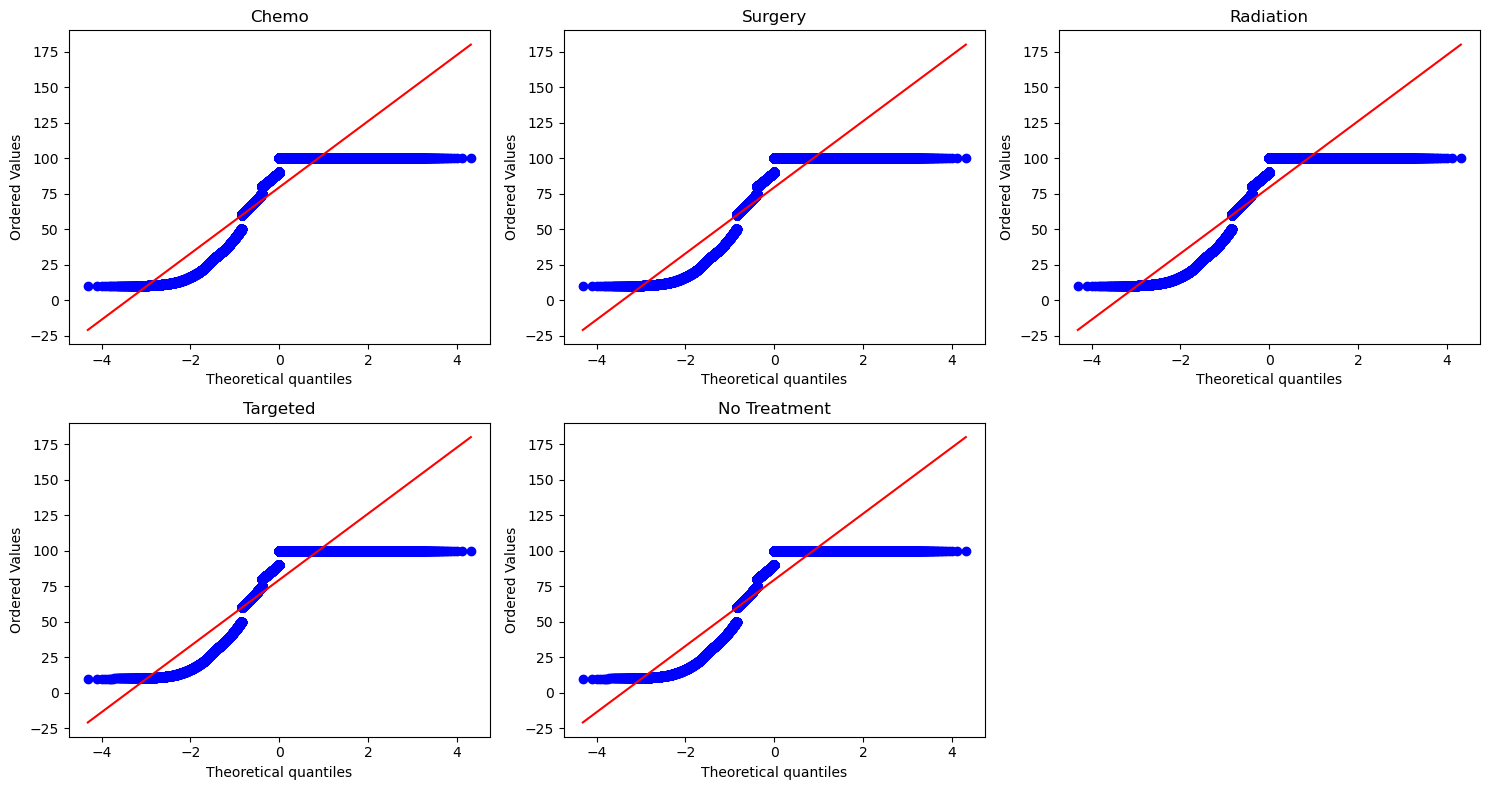

In [27]:
import matplotlib.pyplot as plt
import scipy.stats as stats

dfs = {
    "Chemo": df_chem1,
    "Surgery": df_surg1,
    "Radiation": df_rad1,
    "Targeted": df_targ1,
    "No Treatment": df_notreat1
}

plt.figure(figsize=(15, 8))


#arrumar o df aqui, colocar outro nome 
for i, (name, datafr) in enumerate(dfs.items(), 1):
    plt.subplot(2, 3, i)
    stats.probplot(df['Survival Rate (5-Year, %)'], dist="norm", plot=plt)
    plt.title(name)

plt.tight_layout()
plt.show()


In [28]:
from scipy.stats import skew, kurtosis

for name, datafram in dfs.items():
    s = skew(df['Survival Rate (5-Year, %)'])
    k = kurtosis(df['Survival Rate (5-Year, %)'])  # Fisher definition (normal = 0)
    
    print(f"{name}")
    print(f"Skewness: {s:.3f}")
    print(f"Kurtosis: {k:.3f}")
    print("-"*30)


Chemo
Skewness: -1.079
Kurtosis: -0.140
------------------------------
Surgery
Skewness: -1.079
Kurtosis: -0.140
------------------------------
Radiation
Skewness: -1.079
Kurtosis: -0.140
------------------------------
Targeted
Skewness: -1.079
Kurtosis: -0.140
------------------------------
No Treatment
Skewness: -1.079
Kurtosis: -0.140
------------------------------


In [29]:
from scipy.stats import levene

stat, p = levene(
    df_chem1['Survival Rate (5-Year, %)'],
    df_surg1['Survival Rate (5-Year, %)'],
    df_rad1['Survival Rate (5-Year, %)'],
    df_targ1['Survival Rate (5-Year, %)'],
    df_notreat1['Survival Rate (5-Year, %)']
)

print("Levene p-value:", p)


Levene p-value: 0.23707875811485


In [30]:
from scipy.stats import f_oneway

stat, p = f_oneway(
    df_chem1['Survival Rate (5-Year, %)'],
    df_surg1['Survival Rate (5-Year, %)'],
    df_rad1['Survival Rate (5-Year, %)'],
    df_targ1['Survival Rate (5-Year, %)'],
    df_notreat1['Survival Rate (5-Year, %)']
)

print("ANOVA F-statistic:", stat)
print("ANOVA p-value:", p)


ANOVA F-statistic: 0.593658334734106
ANOVA p-value: 0.6672276618780553


General survival, without stage

In [31]:
df_surg2 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["treatment"] == "surgery")
]

df_rad2 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["treatment"] == "radiation")
]

df_chem2 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["treatment"] == "chemotherapy")
]

df_targ2 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["treatment"] == "targeted therapy")
]

df_notreat2 = df[
    (df["early_dx"] == "yes") &
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["treatment"] == "no treatment")
]

print(df_targ2.shape)
print(df_chem2.shape)
print(df_notreat2.shape)
print(df_rad2.shape)
print(df_surg2.shape)

(4603, 31)
(4686, 31)
(4697, 31)
(4641, 31)
(4581, 31)


In [34]:
stat2, p2 = levene(
    df_chem2['Survival Rate (5-Year, %)'],
    df_surg2['Survival Rate (5-Year, %)'],
    df_rad2['Survival Rate (5-Year, %)'],
    df_targ2['Survival Rate (5-Year, %)'],
    df_notreat2['Survival Rate (5-Year, %)']
)

print("Levene p-value:", p2)

Levene p-value: 0.757795439047821


In [35]:
stat22, p22 = f_oneway(
    df_chem2['Survival Rate (5-Year, %)'],
    df_surg2['Survival Rate (5-Year, %)'],
    df_rad2['Survival Rate (5-Year, %)'],
    df_targ2['Survival Rate (5-Year, %)'],
    df_notreat2['Survival Rate (5-Year, %)']
)

print("ANOVA F-statistic:", stat22)
print("ANOVA p-value:", p22)

ANOVA F-statistic: 0.32957870274255785
ANOVA p-value: 0.8582572789531031


Statistics with clinical factors

In [146]:
df_hpv_y = df[
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["tobacco"] == "yes") &
    (df["Family History of Cancer"] == "Yes") &
    (df["HPV Infection"] == "Yes")
]

df_hpv_y

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
5,6,Taiwan,70,Male,Yes,No,Yes,Yes,No,Yes,...,96504.00,91,Yes,Yes,surgery,yes,yes,2,65+,1-2
74,75,Nigeria,47,Male,Yes,Yes,Yes,No,Yes,Yes,...,28090.00,168,Yes,Yes,targeted therapy,yes,yes,1,45-54,1-2
76,77,UK,62,Female,Yes,No,Yes,Yes,No,No,...,80120.00,40,Yes,Yes,chemotherapy,yes,yes,1,55-64,4-8
164,165,Japan,64,Male,Yes,Yes,Yes,No,No,No,...,46621.75,93,Yes,Yes,no treatment,yes,yes,3,55-64,2-4
219,220,Russia,50,Female,Yes,No,Yes,No,No,Yes,...,54660.00,124,No,Yes,radiation,no,yes,4,45-54,2-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84291,84292,Sri Lanka,50,Male,Yes,Yes,Yes,No,No,Yes,...,100162.50,59,Yes,Yes,chemotherapy,yes,yes,2,45-54,4-8
84343,84344,Sri Lanka,69,Male,Yes,Yes,Yes,No,No,Yes,...,116442.00,147,No,Yes,radiation,no,yes,2,65+,4-8
84365,84366,Russia,54,Male,Yes,No,Yes,No,No,No,...,54393.50,68,Yes,Yes,chemotherapy,yes,yes,3,45-54,4-8
84389,84390,Sri Lanka,50,Male,Yes,Yes,Yes,Yes,Yes,Yes,...,131204.50,131,Yes,Yes,targeted therapy,yes,yes,3,45-54,2-4


In [147]:
df_hpv_n = df[
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["tobacco"] == "yes") &
    (df["Family History of Cancer"] == "Yes") &
    (df["HPV Infection"] == "No")
]

df_hpv_n

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
106,107,Italy,65,Male,Yes,No,No,No,No,No,...,63181.25,174,Yes,Yes,targeted therapy,yes,yes,1,65+,2-4
114,115,Sri Lanka,62,Male,Yes,No,No,No,No,Yes,...,40610.00,172,No,Yes,targeted therapy,no,yes,1,55-64,2-4
281,282,Italy,52,Male,Yes,Yes,No,No,No,No,...,47007.00,156,No,Yes,no treatment,no,yes,2,45-54,4-8
282,283,Pakistan,40,Male,Yes,No,No,Yes,No,Yes,...,39263.00,166,Yes,Yes,targeted therapy,yes,yes,3,35-44,2-4
333,334,Japan,69,Male,Yes,No,No,No,No,Yes,...,73477.50,156,Yes,Yes,surgery,yes,yes,2,65+,4-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84746,84747,USA,56,Male,Yes,Yes,No,No,No,No,...,98831.25,174,Yes,Yes,targeted therapy,yes,yes,1,55-64,2-4
84749,84750,Germany,60,Male,Yes,Yes,No,No,No,Yes,...,56365.50,43,Yes,Yes,targeted therapy,yes,yes,2,55-64,4-8
84865,84866,Japan,63,Male,Yes,No,No,No,No,No,...,123851.00,95,No,Yes,chemotherapy,no,yes,3,55-64,2-4
84875,84876,Germany,56,Male,Yes,Yes,No,No,No,Yes,...,89372.50,38,Yes,Yes,surgery,yes,yes,1,55-64,4-8


In [148]:
from scipy.stats import skew, kurtosis

for name, datafr2 in [("Group1", df_hpv_n), ("Group2", df_hpv_y)]:
    print(name)
    print("Skew:", skew(df['Survival Rate (5-Year, %)']))
    print("Kurtosis:", kurtosis(df['Survival Rate (5-Year, %)']))
    print("-"*30)


Group1
Skew: -1.0789643582416752
Kurtosis: -0.13976301786325385
------------------------------
Group2
Skew: -1.0789643582416752
Kurtosis: -0.13976301786325385
------------------------------


In [149]:
from scipy.stats import levene

stat, p = levene(df_hpv_n['Survival Rate (5-Year, %)'], df_hpv_y['Survival Rate (5-Year, %)'])
print("Levene p-value:", p)


Levene p-value: 0.22895704751856877


In [150]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(df_hpv_n['Survival Rate (5-Year, %)'],
                    df_hpv_y['Survival Rate (5-Year, %)'],
                    equal_var=True)

print("t-test p-value:", p)


t-test p-value: 0.11388896083065446


Clinical only stage 4

In [37]:
df_st4_chemo = df[
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["tobacco"] == "yes") &
    (df["Family History of Cancer"] == "Yes") &
    (df["HPV Infection"] == "Yes") &
    (df["stage"] == 4) &
    (df["treatment"] == "chemotherapy")
]

df_st4_chemo

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
1273,1274,Taiwan,41,Male,Yes,No,Yes,Yes,No,Yes,...,61330.0,165,Yes,Yes,chemotherapy,yes,yes,4,35-44,2-4
1472,1473,UK,43,Female,Yes,Yes,Yes,No,No,Yes,...,101102.0,45,Yes,Yes,chemotherapy,yes,yes,4,35-44,2-4
1649,1650,Sri Lanka,74,Male,Yes,No,Yes,No,No,Yes,...,58374.0,172,Yes,Yes,chemotherapy,yes,yes,4,65+,2-4
3787,3788,Australia,39,Male,Yes,Yes,Yes,No,No,Yes,...,89306.0,39,No,Yes,chemotherapy,no,yes,4,35-44,4-8
5845,5846,Russia,57,Male,Yes,Yes,Yes,No,No,Yes,...,53982.0,101,No,Yes,chemotherapy,no,yes,4,55-64,2-4
7617,7618,Egypt,42,Male,Yes,Yes,Yes,No,Yes,Yes,...,105214.0,158,Yes,Yes,chemotherapy,yes,yes,4,35-44,2-4
11454,11455,Australia,51,Female,Yes,No,Yes,No,No,No,...,104082.0,35,Yes,Yes,chemotherapy,yes,yes,4,45-54,2-4
12513,12514,Italy,69,Male,Yes,Yes,Yes,No,No,No,...,97642.0,64,Yes,Yes,chemotherapy,yes,yes,4,65+,2-4
12544,12545,Brazil,41,Male,Yes,Yes,Yes,No,No,No,...,56134.0,99,Yes,Yes,chemotherapy,yes,yes,4,35-44,4-8
14159,14160,Taiwan,55,Male,Yes,No,Yes,Yes,Yes,Yes,...,131548.0,151,No,Yes,chemotherapy,no,yes,4,55-64,2-4


In [38]:
df_st4_all = df[
    (df["Oral Cancer (Diagnosis)"] == "Yes") &
    (df["tobacco"] == "yes") &
    (df["Family History of Cancer"] == "Yes") &
    (df["HPV Infection"] == "Yes") &
    (df["stage"] == 4) &
    (df["treatment"] != "chemotherapy")
]

df_st4_all

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),treatment,early_dx,tobacco,stage,age_group,tumor_bin
219,220,Russia,50,Female,Yes,No,Yes,No,No,Yes,...,54660.0,124,No,Yes,radiation,no,yes,4,45-54,2-4
394,395,Australia,52,Male,Yes,Yes,Yes,No,Yes,Yes,...,154062.0,141,Yes,Yes,targeted therapy,yes,yes,4,45-54,4-8
697,698,Japan,55,Male,Yes,Yes,Yes,No,No,Yes,...,57482.0,41,No,Yes,targeted therapy,no,yes,4,55-64,2-4
805,806,Taiwan,34,Male,Yes,No,Yes,Yes,No,No,...,154952.0,158,Yes,Yes,targeted therapy,yes,yes,4,<35,4-8
972,973,India,49,Female,Yes,Yes,Yes,Yes,No,Yes,...,126624.0,87,No,Yes,radiation,no,yes,4,45-54,2-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81708,81709,India,42,Male,Yes,No,Yes,Yes,No,No,...,86630.0,126,No,Yes,radiation,no,yes,4,35-44,2-4
83357,83358,Sri Lanka,49,Male,Yes,No,Yes,Yes,No,Yes,...,96928.0,44,Yes,Yes,targeted therapy,yes,yes,4,45-54,1-2
83752,83753,Germany,49,Male,Yes,Yes,Yes,No,No,Yes,...,44576.0,155,Yes,Yes,targeted therapy,yes,yes,4,45-54,4-8
84209,84210,Italy,73,Male,Yes,No,Yes,No,No,No,...,131324.0,121,Yes,Yes,surgery,yes,yes,4,65+,4-8


In [39]:
stat13, p13 = levene(df_st4_all['Survival Rate (5-Year, %)'], df_st4_chemo['Survival Rate (5-Year, %)'])
print("Levene p-value:", p13)

Levene p-value: 0.10494636361732328


In [41]:
print("Skew:", skew(df_st4_chemo['Survival Rate (5-Year, %)']))
print("Kurtosis:", kurtosis(df_st4_chemo['Survival Rate (5-Year, %)']))

Skew: 0.28119304023606273
Kurtosis: -1.5842784732189967


In [43]:
from scipy.stats import ttest_ind

stat14, p14 = ttest_ind(df_st4_all['Survival Rate (5-Year, %)'],
                    df_st4_chemo['Survival Rate (5-Year, %)'],
                    equal_var=True)

print("t-test p-value:", p14)

t-test p-value: 0.2503918090123152


In [48]:
from scipy.stats import kruskal

groups = [g['Survival Rate (5-Year, %)'].values 
          for _, g in df.groupby('stage')]

stat, p = kruskal(*groups)
print("Stage effect p-value:", p)


Stage effect p-value: 0.0


In [49]:
df.groupby('stage')['Survival Rate (5-Year, %)'].median()

stage
0    100.000000
1     84.983621
2     67.462702
3     39.941541
4     20.161377
Name: Survival Rate (5-Year, %), dtype: float64

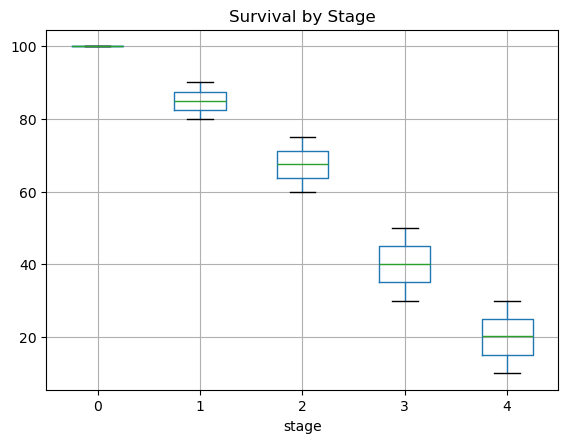

In [50]:
import matplotlib.pyplot as plt

df.boxplot(column='Survival Rate (5-Year, %)', by='stage')
plt.title("Survival by Stage")
plt.suptitle("")
plt.show()


In [69]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

value_col = "Survival Rate (5-Year, %)"
group_col = "stage"   # or "Cancer Stage" depending on your df

# Build arrays per stage
groups = {
    str(stage): df.loc[df[group_col] == stage, value_col].dropna().values
    for stage in sorted(df[group_col].dropna().unique())
}

# Pairwise tests
rows, pvals = [], []
for s1, s2 in combinations(groups.keys(), 2):
    u, p = mannwhitneyu(groups[s1], groups[s2], alternative="two-sided")
    rows.append({
        "stage1": s1,
        "stage2": s2,
        "n1": len(groups[s1]),
        "n2": len(groups[s2]),
        "median1": float(np.median(groups[s1])),
        "median2": float(np.median(groups[s2])),
        "median_diff": float(np.median(groups[s1]) - np.median(groups[s2])),
        "p_raw": p
    })
    pvals.append(p)

res = pd.DataFrame(rows).sort_values("p_raw").reset_index(drop=True)

# Multiple-testing correction (Holm is a good default)
res["p_holm"] = multipletests(res["p_raw"], method="holm")[1]

# Show significant stage pairs
res_sig = res[res["p_holm"] < 0.05]
print("Significant stage differences (Holm-corrected):")
display(res_sig)

# Optional: show full table
# display(res)


Significant stage differences (Holm-corrected):


,stage1,stage2,n1,n2,median1,median2,median_diff,p_raw,p_holm
0,0,1,42573,12713,100.000000,84.983621,15.016379,0.0,0.0
1,0,2,42573,12865,100.000000,67.462702,32.537298,0.0,0.0
2,0,3,42573,10520,100.000000,39.941541,60.058459,0.0,0.0
3,0,4,42573,6251,100.000000,20.161377,79.838623,0.0,0.0
4,1,2,12713,12865,84.983621,67.462702,17.520918,0.0,0.0
5,1,3,12713,10520,84.983621,39.941541,45.042079,0.0,0.0
6,1,4,12713,6251,84.983621,20.161377,64.822244,0.0,0.0
7,2,3,12865,10520,67.462702,39.941541,27.521161,0.0,0.0
8,2,4,12865,6251,67.462702,20.161377,47.301325,0.0,0.0
9,3,4,10520,6251,39.941541,20.161377,19.780164,0.0,0.0


Lung cancer dataset

In [51]:
df1 = pd.read_csv("LungCanC2024_Dataset.csv")

In [52]:
df1

,nodule_size_mm,nodule_texture,HU_mean,HU_std,GLCM_contrast,GLCM_correlation,PET_SUVmax,PET_SUVmean,patient_age,patient_gender,...,targeted_therapy_received,EGFR_mutation_status,KRAS_mutation_status,ALK_fusion_status,PD-L1_expression_level,tumor_mutational_burden,cancer_presence,cancer_subtype,cancer_stage,survival_time_months
0,3.754145,0.779723,-719.889488,160.069061,11.093420,0.877811,0.964536,1.896542,85,Male,...,0,0,1,0,42.178630,0.413221,1,No Cancer,Stage II,23.916617
1,24.080971,0.873834,-259.176808,122.088962,2.739776,0.610637,12.441004,0.501087,81,Male,...,0,1,1,0,97.468371,0.763461,1,Squamous Cell,Stage III,11.859306
2,10.533966,0.728628,-757.122831,135.105965,0.115492,0.524141,9.711270,0.356903,64,Male,...,0,1,0,1,95.115583,4.357365,0,Adenocarcinoma,Stage I,14.177438
3,7.303540,0.826359,-249.694708,242.576964,2.941016,0.507490,2.817405,2.744690,85,Male,...,0,0,0,1,28.871351,1.288862,1,No Cancer,No Cancer,37.703014
4,1.356999,0.490455,-697.653568,44.987641,4.093630,0.543351,0.396519,2.753422,38,Male,...,0,0,0,0,64.792249,6.477791,1,Squamous Cell,No Cancer,2.828828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289005,5.692908,0.795661,-473.769033,96.933585,6.182570,0.907243,3.447298,3.926381,59,Male,...,0,1,0,0,35.160862,3.473066,0,Adenocarcinoma,Stage III,51.959098
289006,12.854063,0.743441,-460.353937,127.992305,4.128543,0.605269,2.010501,0.647157,59,Male,...,0,1,0,0,73.951157,8.655506,0,Squamous Cell,Stage III,41.313700
289007,9.593239,0.435653,-700.230996,76.769656,2.438749,0.691241,2.732887,4.667872,56,Male,...,1,0,0,1,77.317362,0.257364,1,Squamous Cell,Stage II,1.190385
289008,0.739932,0.931631,-306.791455,206.641993,4.428975,0.909086,3.924125,1.194951,69,Female,...,0,0,0,0,19.889303,3.445872,1,SCLC,Stage II,2.320116


In [ ]:
#df1 = df1.reset_index(drop=True)
#df1['id'] = df1.index + 1
#df1.to_csv("tableau_ready.csv", index=False)

In [53]:
df1_immuno = df1[
    (df1["cancer_presence"] == 1) &
    (df1["cancer_stage"] == "Stage I") &
    (df1["immunotherapy_received"] == 1)
]

df1_rad = df1[
    (df1["cancer_presence"] == 1) &
    (df1["cancer_stage"] == "Stage I") &
    (df1["radiation_therapy"] == 1)
]

df1_chem = df1[
    (df1["cancer_presence"] == 1) &
    (df1["cancer_stage"] == "Stage I") &
    (df1["chemotherapy_received"] == 1)
]

df1_targ = df1[
    (df1["cancer_presence"] == 1) &
    (df1["cancer_stage"] == "Stage I") &
    (df1["targeted_therapy_received"] == 1)
]

df1_notreat = df1[
    (df1["cancer_presence"] == 1) &
    (df1["cancer_stage"] == "Stage I") &
    (df1["targeted_therapy_received"] == 0) &
    (df1["chemotherapy_received"] == 0) &
    (df1["radiation_therapy"] == 0) &
    (df1["immunotherapy_received"] == 0)
]

print(df1_targ.shape)
print(df1_chem.shape)
print(df1_notreat.shape)
print(df1_rad.shape)
print(df1_immuno.shape)

(4300, 27)
(12791, 27)
(6824, 27)
(9881, 27)
(5669, 27)


In [55]:
from scipy.stats import skew, kurtosis

df1s = {
    "Targeted": df1_targ,
    "Chemo": df1_chem,
    "No treat": df1_notreat,
    "Rad": df1_rad,
    "Immuno": df1_immuno
}

for name, df1rame in df1s.items():
    print(name)
    print("Skew:", skew(df1rame['survival_time_months']))
    print("Kurtosis:", kurtosis(df1rame['survival_time_months']))
    print("-"*30)


Targeted
Skew: 1.9815397659628888
Kurtosis: 5.686218073783532
------------------------------
Chemo
Skew: 1.976903832148655
Kurtosis: 6.0006678927970665
------------------------------
No treat
Skew: 1.9868523132914073
Kurtosis: 5.844219121993133
------------------------------
Rad
Skew: 1.9486626259354913
Kurtosis: 5.627372814220845
------------------------------
Immuno
Skew: 1.963421705100231
Kurtosis: 5.606951559202228
------------------------------


In [56]:
from scipy.stats import kruskal

stat21, p21 = kruskal(
    df1_targ['survival_time_months'],
    df1_chem['survival_time_months'],
    df1_notreat['survival_time_months'],
    df1_rad['survival_time_months'],
    df1_immuno['survival_time_months']
)

print("Kruskal-Wallis p-value:", p21)


Kruskal-Wallis p-value: 0.7912734053905048


General difference between treatments:

In [57]:
df1_immuno1 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["immunotherapy_received"] == 1)
]

df1_rad1 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["radiation_therapy"] == 1)
]

df1_chem1 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["chemotherapy_received"] == 1)
]

df1_targ1 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["targeted_therapy_received"] == 1)
]

df1_notreat1 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["targeted_therapy_received"] == 0) &
    (df1["chemotherapy_received"] == 0) &
    (df1["radiation_therapy"] == 0) &
    (df1["immunotherapy_received"] == 0)
]

print(df1_targ1.shape)
print(df1_chem1.shape)
print(df1_notreat1.shape)
print(df1_rad1.shape)
print(df1_immuno1.shape)

(28339, 27)
(84645, 27)
(45461, 27)
(65652, 27)
(37801, 27)


In [58]:
from scipy.stats import skew, kurtosis

df1s1 = {
    "Targeted": df1_targ1,
    "Chemo": df1_chem1,
    "No treat": df1_notreat1,
    "Rad": df1_rad1,
    "Immuno": df1_immuno1
}

for name1, df1rame1 in df1s1.items():
    print(name)
    print("Skew:", skew(df1rame1['survival_time_months']))
    print("Kurtosis:", kurtosis(df1rame1['survival_time_months']))
    print("-"*30)

Immuno
Skew: 1.9070262839788892
Kurtosis: 5.041084293453897
------------------------------
Immuno
Skew: 2.0068840854034136
Kurtosis: 6.152870775620455
------------------------------
Immuno
Skew: 1.9744632891270637
Kurtosis: 5.563751875130766
------------------------------
Immuno
Skew: 2.0307115652005123
Kurtosis: 6.473741451846278
------------------------------
Immuno
Skew: 1.949069407380642
Kurtosis: 5.428426611720466
------------------------------


In [59]:
from scipy.stats import kruskal

stat222, p222 = kruskal(
    df1_targ1['survival_time_months'],
    df1_chem1['survival_time_months'],
    df1_notreat1['survival_time_months'],
    df1_rad1['survival_time_months'],
    df1_immuno1['survival_time_months']
)

print("Kruskal-Wallis p-value:", p222)

Kruskal-Wallis p-value: 0.9126297052371083


In [70]:
df1_targ2 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["smoking_history"] == "Never") &
    (df1["family_history"] == 1) &
    (df1["cancer_stage"] == "Stage II") &
    (df1["targeted_therapy_received"] == 1)
]

df1_immuno2 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["smoking_history"] == "Never") &
    (df1["family_history"] == 1) &
    (df1["cancer_stage"] == "Stage II") &
    (df1["immunotherapy_received"] == 1)
]

df1_rad2 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["smoking_history"] == "Never") &
    (df1["family_history"] == 1) &
    (df1["cancer_stage"] == "Stage II") &
    (df1["radiation_therapy"] == 1)
]

df1_chem2 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["smoking_history"] == "Never") &
    (df1["family_history"] == 1) &
    (df1["cancer_stage"] == "Stage II") &
    (df1["chemotherapy_received"] == 1)
]

df1_notreat2 = df1[
    (df1["cancer_presence"] == 1) &
    (df1["smoking_history"] == "Never") &
    (df1["family_history"] == 1) &
    (df1["cancer_stage"] == "Stage II") &
    (df1["targeted_therapy_received"] == 0) &
    (df1["chemotherapy_received"] == 0) &
    (df1["radiation_therapy"] == 0) &
    (df1["immunotherapy_received"] == 0)
]

print(df1_targ2.shape)
print(df1_chem2.shape)
print(df1_notreat2.shape)
print(df1_rad2.shape)
print(df1_immuno2.shape)

(451, 27)
(1214, 27)
(688, 27)
(1041, 27)
(584, 27)


In [71]:
from scipy.stats import skew, kurtosis

df1s2 = {
    "Targeted": df1_targ2,
    "Chemo": df1_chem2,
    "No treat": df1_notreat2,
    "Rad": df1_rad2,
    "Immuno": df1_immuno2
}

for name2, df1rame2 in df1s2.items():
    print(name)
    print("Skew:", skew(df1rame2['survival_time_months']))
    print("Kurtosis:", kurtosis(df1rame2['survival_time_months']))
    print("-"*30)

Immuno
Skew: 1.8232120975842296
Kurtosis: 4.125023982937328
------------------------------
Immuno
Skew: 2.106512386464151
Kurtosis: 6.284746906090897
------------------------------
Immuno
Skew: 2.1281194340710066
Kurtosis: 6.012192366462797
------------------------------
Immuno
Skew: 1.9935490358191437
Kurtosis: 5.119090483213393
------------------------------
Immuno
Skew: 1.8775310514283474
Kurtosis: 4.796040711218587
------------------------------


In [72]:
stat2222, p2222 = kruskal(
    df1_targ2['survival_time_months'],
    df1_chem2['survival_time_months'],
    df1_notreat2['survival_time_months'],
    df1_rad2['survival_time_months'],
    df1_immuno2['survival_time_months']
)

print("Kruskal-Wallis p-value:", p2222)

Kruskal-Wallis p-value: 0.03516908960516422


In [73]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# 1) Put your groups in a dict
groups = {
    "Targeted":   df1_targ2["survival_time_months"].dropna().values,
    "Chemo":      df1_chem2["survival_time_months"].dropna().values,
    "No_Treat":   df1_notreat2["survival_time_months"].dropna().values,
    "Radiation":  df1_rad2["survival_time_months"].dropna().values,
    "Immuno":     df1_immuno2["survival_time_months"].dropna().values
}

# 2) Pairwise Mann–Whitney tests
rows = []
pvals = []

for g1, g2 in combinations(groups.keys(), 2):
    u, p = mannwhitneyu(groups[g1], groups[g2], alternative="two-sided")
    rows.append({
        "group1": g1,
        "group2": g2,
        "median1": float(np.median(groups[g1])),
        "median2": float(np.median(groups[g2])),
        "median_diff": float(np.median(groups[g1]) - np.median(groups[g2])),
        "p_raw": p
    })
    pvals.append(p)

res = pd.DataFrame(rows).sort_values("p_raw").reset_index(drop=True)

# 3) Multiple testing correction (Holm is a good default)
res["p_holm"] = multipletests(res["p_raw"], method="holm")[1]

# 4) Show only significant comparisons
print("Significant pairwise differences (Holm-corrected):")
display(res[res["p_holm"] < 0.05])

# Optional: show full table
# display(res)

# Optional: show medians by group
medians = {k: np.median(v) for k, v in groups.items()}
display(pd.Series(medians).sort_values(ascending=False).rename("median_survival_months"))


Significant pairwise differences (Holm-corrected):


,group1,group2,median1,median2,median_diff,p_raw,p_holm
0,No_Treat,Immuno,15.209901,18.356847,-3.146946,0.004389,0.043892


Immuno       18.356847
Radiation    17.565456
Chemo        16.803528
Targeted     16.634223
No_Treat     15.209901
Name: median_survival_months, dtype: float64

In [74]:
from scipy.stats import ttest_ind

stat1e2, p1e2 = ttest_ind(df1_notreat2['survival_time_months'],
                    df1_targ2['survival_time_months'],
                    equal_var=True)

print("t-test p-value:", p1e2)

t-test p-value: 0.021933547009363313


In [75]:
len(df1_chem2), len(df1_rad2), len(df1_immuno2), len(df1_targ2), len(df1_notreat2)


(1214, 1041, 584, 451, 688)

      treatment     n       mean        std
3      Targeted   451  26.383288  27.038804
2        Immuno   584  25.305974  23.893267
1     Radiation  1041  24.570660  24.696971
0         Chemo  1214  23.481291  23.717729
4  No Treatment   688  22.850920  24.280066


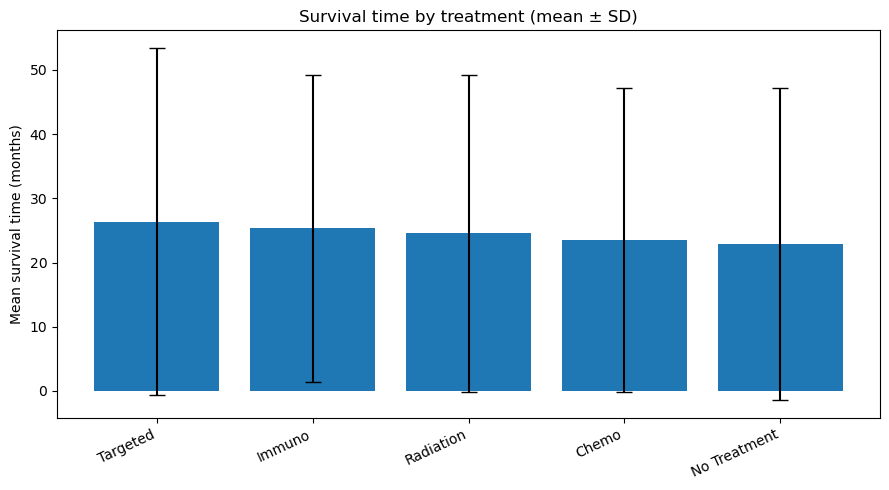

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Put your dataframes in a dict (label -> df)
dfs = {
    "Chemo": df1_chem2,
    "Radiation": df1_rad2,
    "Immuno": df1_immuno2,
    "Targeted": df1_targ2,
    "No Treatment": df1_notreat2
}

# 2) Compute mean and std for each group
rows = []
for name, d in dfs.items():
    x = d["survival_time_months"].dropna().values
    rows.append({
        "treatment": name,
        "n": len(x),
        "mean": np.mean(x),
        "std": np.std(x, ddof=1)  # sample standard deviation
    })

stats_df = pd.DataFrame(rows).sort_values("mean", ascending=False)
print(stats_df)

# 3) Plot: bar chart with SD error bars
plt.figure(figsize=(9, 5))
plt.bar(
    stats_df["treatment"],
    stats_df["mean"],
    yerr=stats_df["std"],
    capsize=6
)
plt.ylabel("Mean survival time (months)")
plt.title("Survival time by treatment (mean ± SD)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
